# Pracownia 4

## Importy

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats import boxcox

## Zadanie 1

Równanie regresji: y = -0.5802 + 15.0352 * x
Teoretyczne: Intercept=-0.5802, Slope=15.0352
Wbudowane:   Intercept=-0.5802, Slope=15.0352


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_11118/3966182221.py:2: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv('../data/CH01PR20.txt', sep='\s+', header=None, names=['y', 'x'])


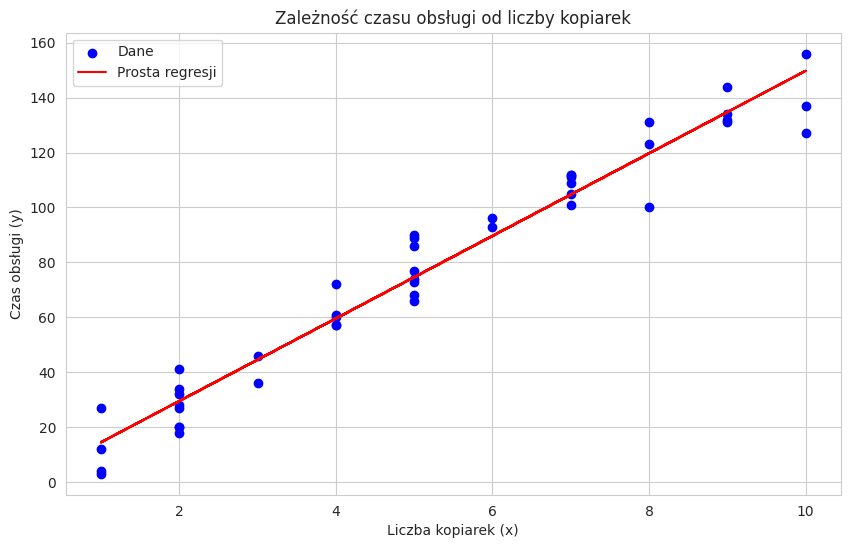

Wniosek: Zależność wydaje się być silnie liniowa.


In [3]:
# ch01pr20.txt: col1=czas (y), col2=liczba kopiarek (x)
data = pd.read_csv('../data/CH01PR20.txt', sep='\s+', header=None, names=['y', 'x'])

X = data['x']
Y = data['y']
n = len(data)

x_mean = np.mean(X)
y_mean = np.mean(Y)

b1 = np.sum((X - x_mean) * (Y - y_mean)) / np.sum((X - x_mean)**2)
b0 = y_mean - b1 * x_mean

X_with_const = sm.add_constant(X)
model = sm.OLS(Y, X_with_const).fit()
b0_builtin, b1_builtin = model.params

print(f"Równanie regresji: y = {b0:.4f} + {b1:.4f} * x")
print(f"Teoretyczne: Intercept={b0:.4f}, Slope={b1:.4f}")
print(f"Wbudowane:   Intercept={b0_builtin:.4f}, Slope={b1_builtin:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Dane')
plt.plot(X, b0 + b1*X, color='red', label='Prosta regresji')
plt.xlabel('Liczba kopiarek (x)')
plt.ylabel('Czas obsługi (y)')
plt.title('Zależność czasu obsługi od liczby kopiarek')
plt.legend()
plt.show()

print("Wniosek: Zależność wydaje się być silnie liniowa.")

In [4]:
SSE = np.sum((Y - (b0 + b1*X))**2)
MSE = SSE / (n - 2)
SXX = np.sum((X - x_mean)**2)

se_b1 = np.sqrt(MSE / SXX)
se_b0 = np.sqrt(MSE * (1/n + x_mean**2 / SXX))

t_crit = stats.t.ppf(0.975, n - 2)

conf_b1 = (b1 - t_crit * se_b1, b1 + t_crit * se_b1)
conf_b0 = (b0 - t_crit * se_b0, b0 + t_crit * se_b0)

print("--- PUNKT B (Przedziały ufności 95%) ---")
print(f"Slope (Teoretycznie): {conf_b1}")
print(f"Slope (Wbudowane):    {model.conf_int().loc['x'].values}")
print(f"Intercept (Teoretycznie): {conf_b0}")
print(f"Intercept (Wbudowane):    {model.conf_int().loc['const'].values}")

--- PUNKT B (Przedziały ufności 95%) ---
Slope (Teoretycznie): (np.float64(14.06100982665068), np.float64(16.00948625690023))
Slope (Wbudowane):    [14.06100983 16.00948626]
Intercept (Teoretycznie): (np.float64(-6.234842799781703), np.float64(5.074529483854818))
Intercept (Wbudowane):    [-6.2348428   5.07452948]


In [5]:
y_hat = b0 + b1 * X
SSE = np.sum((Y - y_hat)**2)
MSE = SSE / (n - 2)
SXX = np.sum((X - x_mean)**2)

se_b1_theo = np.sqrt(MSE / SXX)
se_b0_theo = np.sqrt(MSE * (1/n + x_mean**2 / SXX))

t_stat_b1_theo = b1 / se_b1_theo
t_stat_b0_theo = b0 / se_b0_theo

p_val_b1_theo = 2 * (1 - stats.t.cdf(np.abs(t_stat_b1_theo), n - 2))
p_val_b0_theo = 2 * (1 - stats.t.cdf(np.abs(t_stat_b0_theo), n - 2))

t_stat_builtin = model.tvalues
p_vals_builtin = model.pvalues

print(f"Slope (Teoretycznie): Statystyka: {t_stat_b1_theo:.4f}, P-wartość: {p_val_b1_theo:.4f}")
print(f"Slope (Wbudowane): Statystyka: {t_stat_builtin['x']:.4f}, P-wartość: {p_vals_builtin['x']:.4f}")
print(f"Intercept (Teoretycznie): Statystyka: {t_stat_b0_theo:.4f}, P-wartość: {p_val_b0_theo:.4f}")
print(f"Intercept (Wbudowane): Statystyka: {t_stat_builtin['const']:.4f}, P-wartość: {p_vals_builtin['const']:.4f}")

Slope (Teoretycznie): Statystyka: 31.1233, P-wartość: 0.0000
Slope (Wbudowane): Statystyka: 31.1233, P-wartość: 0.0000
Intercept (Teoretycznie): Statystyka: -0.2069, P-wartość: 0.8371
Intercept (Wbudowane): Statystyka: -0.2069, P-wartość: 0.8371


In [17]:
k_values = np.array([1, 5, 8, 11, 25, 100])
k_values_with_const = sm.add_constant(k_values)

results_d_theo = []
for k in k_values:
    y_hat_k = b0 + b1 * k
    se_ci = np.sqrt(MSE * (1/n + (k - x_mean)**2 / SXX))
    ci_low = y_hat_k - t_crit * se_ci
    ci_high = y_hat_k + t_crit * se_ci
    results_d_theo.append([k, y_hat_k, ci_low, ci_high, ci_high - ci_low])

df_d_theo = pd.DataFrame(results_d_theo, columns=['k', 'Estymator', 'CI_Low_Theo', 'CI_High_Theo', 'Długość_CI'])

predictions = model.get_prediction(k_values_with_const)
df_builtin = predictions.summary_frame(alpha=0.05)

print("PUNKT D: 95% Przedziały Ufności (CI) dla wartości oczekiwanej")
summary_d = pd.DataFrame({
    'k': k_values,
    'Estymator': df_d_theo['Estymator'],
    'CI Teoretyczny': df_d_theo.apply(lambda r: f"[{r['CI_Low_Theo']:.2f}, {r['CI_High_Theo']:.2f}]", axis=1),
    'CI Wbudowany': df_builtin.apply(lambda r: f"[{r['mean_ci_lower']:.2f}, {r['mean_ci_upper']:.2f}]", axis=1),
    'Długość CI': df_d_theo['Długość_CI']
})
print(summary_d.to_markdown(index=False))

print(f"\nŚrednia liczba maszyn w próbie (x_mean) = {x_mean:.2f}")

PUNKT D: 95% Przedziały Ufności (CI) dla wartości oczekiwanej
|   k |   Estymator | CI Teoretyczny     | CI Wbudowany       |   Długość CI |
|----:|------------:|:-------------------|:-------------------|-------------:|
|   1 |     14.4551 | [9.64, 19.27]      | [9.64, 19.27]      |      9.6379  |
|   5 |     74.5961 | [71.91, 77.28]     | [71.91, 77.28]     |      5.36372 |
|   8 |    119.702  | [115.82, 123.59]   | [115.82, 123.59]   |      7.77223 |
|  11 |    164.808  | [158.48, 171.14]   | [158.48, 171.14]   |     12.6643  |
|  25 |    375.301  | [355.74, 394.86]   | [355.74, 394.86]   |     39.1219  |
| 100 |   1502.94   | [1410.46, 1595.43] | [1410.46, 1595.43] |    184.966   |

Średnia liczba maszyn w próbie (x_mean) = 5.11


In [8]:
results_e_theo = []
for k in k_values:
    y_hat_k = b0 + b1 * k
    se_pi = np.sqrt(MSE * (1 + 1/n + (k - x_mean)**2 / SXX))
    pi_low = y_hat_k - t_crit * se_pi
    pi_high = y_hat_k + t_crit * se_pi
    results_e_theo.append([k, y_hat_k, pi_low, pi_high, pi_high - pi_low])

df_e_theo = pd.DataFrame(results_e_theo, columns=['k', 'Predykcja', 'PI_Low_Theo', 'PI_High_Theo', 'Długość_PI'])

print("PUNKT E: 95% Przedziały Predykcyjne (PI) dla nowej obserwacji")
summary_e = pd.DataFrame({
    'k': k_values,
    'Predykcja': df_e_theo['Predykcja'],
    'PI Teoretyczny': df_e_theo.apply(lambda r: f"[{r['PI_Low_Theo']:.2f}, {r['PI_High_Theo']:.2f}]", axis=1),
    'PI Wbudowany': df_builtin.apply(lambda r: f"[{r['obs_ci_lower']:.2f}, {r['obs_ci_upper']:.2f}]", axis=1),
    'Długość PI': df_e_theo['Długość_PI']
})
print(summary_e.to_markdown(index=False))

PUNKT E: 95% Przedziały Predykcyjne (PI) dla nowej obserwacji
|   k |   Predykcja | PI Teoretyczny     | PI Wbudowany       |   Długość PI |
|----:|------------:|:-------------------|:-------------------|-------------:|
|   1 |     14.4551 | [-4.16, 33.07]     | [-4.16, 33.07]     |      37.2211 |
|   5 |     74.5961 | [56.42, 92.77]     | [56.42, 92.77]     |      36.3495 |
|   8 |    119.702  | [101.31, 138.09]   | [101.31, 138.09]   |      36.7821 |
|  11 |    164.808  | [145.75, 183.87]   | [145.75, 183.87]   |      38.1169 |
|  25 |    375.301  | [348.73, 401.87]   | [348.73, 401.87]   |      53.1323 |
| 100 |   1502.94   | [1408.73, 1597.16] | [1408.73, 1597.16] |     188.428  |


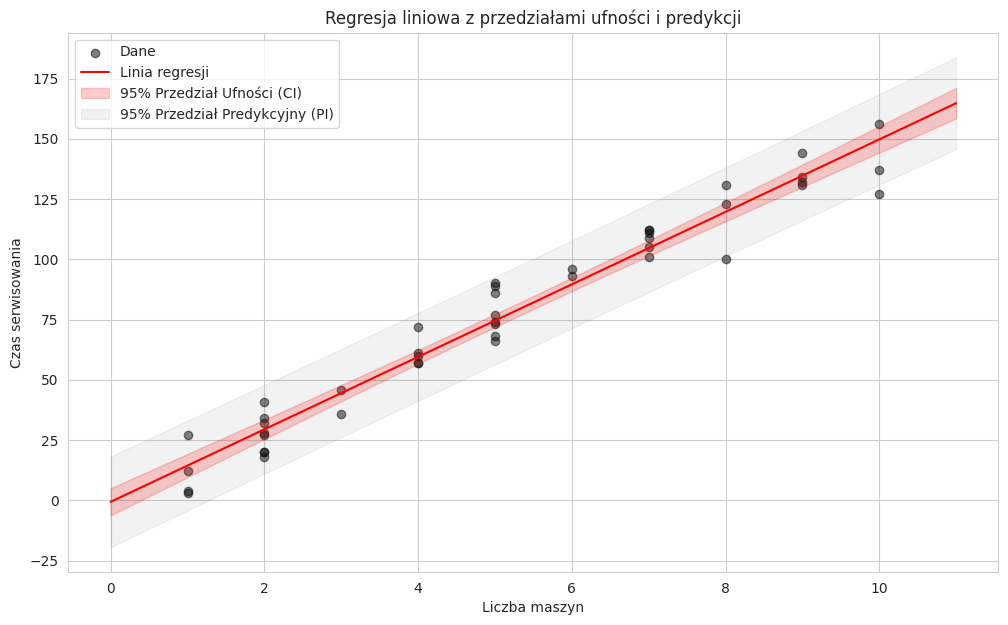

In [7]:
x_range = np.linspace(X.min()-1, X.max()+1, 100)
x_range_const = sm.add_constant(x_range)

predictions = model.get_prediction(x_range_const)
frame = predictions.summary_frame(alpha=0.05)

plt.figure(figsize=(12, 7))
plt.scatter(X, Y, color='black', label='Dane', alpha=0.5)
plt.plot(x_range, frame['mean'], color='red', label='Linia regresji')

plt.fill_between(x_range, frame['mean_ci_lower'], frame['mean_ci_upper'],
                 color='red', alpha=0.2, label='95% Przedział Ufności (CI)')

plt.fill_between(x_range, frame['obs_ci_lower'], frame['obs_ci_upper'],
                 color='gray', alpha=0.1, label='95% Przedział Predykcyjny (PI)')

plt.xlabel('Liczba maszyn')
plt.ylabel('Czas serwisowania')
plt.title('Regresja liniowa z przedziałami ufności i predykcji')
plt.legend()
plt.show()

## Zadanie 2

Równanie regresji: GPA = -3.5571 + 0.1010 * IQ
R^2 (Teoretyczne): 0.4016
R^2 (Wbudowane):   0.4016


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_11118/3513534290.py:3: SyntaxWarning: invalid escape sequence '\s'
  df2 = pd.read_csv('../data/tabela1_6.txt', sep='\s+', header=None, names=['id', 'GPA', 'IQ', 'Gender', 'PH'])
/tmp/ipykernel_11118/3513534290.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Równanie regresji: GPA = {model_iq.params[0]:.4f} + {model_iq.params[1]:.4f} * IQ")


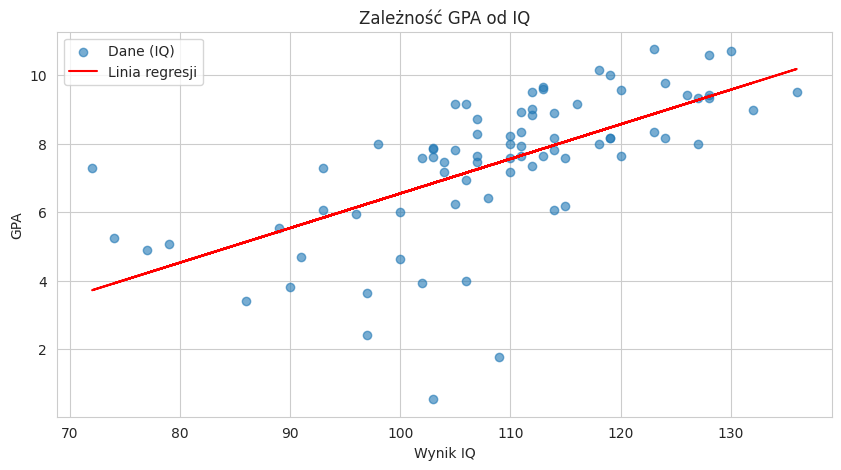

In [20]:
# Wczytanie danych (kolumny: 1-ID, 2-GPA, 3-IQ, 4-Gender, 5-PH)
df2 = pd.read_csv('../data/tabela1_6.txt', sep='\s+', header=None, names=['id', 'GPA', 'IQ', 'Gender', 'PH'])

y = df2['GPA']
x_iq = df2['IQ']
n = len(df2)

X_iq_const = sm.add_constant(x_iq)
model_iq = sm.OLS(y, X_iq_const).fit()

y_hat = model_iq.predict(X_iq_const)
SST = np.sum((y - np.mean(y))**2)
SSE = np.sum((y - y_hat)**2)
r2_theo = 1 - (SSE / SST)

print(f"Równanie regresji: GPA = {model_iq.params[0]:.4f} + {model_iq.params[1]:.4f} * IQ")
print(f"R^2 (Teoretyczne): {r2_theo:.4f}")
print(f"R^2 (Wbudowane): {model_iq.rsquared:.4f}")

plt.figure(figsize=(10, 5))
plt.scatter(x_iq, y, alpha=0.6, label='Dane (IQ)')
plt.plot(x_iq, y_hat, color='red', label='Linia regresji')
plt.xlabel('Wynik IQ')
plt.ylabel('GPA')
plt.title('Zależność GPA od IQ')
plt.legend()
plt.show()


In [30]:
df1 = 1
df2_err = n - 2

MSR = (SST - SSE) / df1
MSE = SSE / df2_err

f_stat_theo = MSR / MSE
p_val_f_theo = 1 - stats.f.cdf(f_stat_theo, df1, df2_err)

f_stat_builtin = model_iq.fvalue
p_val_f_builtin = model_iq.f_pvalue

print("TEST F ISTOTNOŚCI MODELU (GPA vs IQ)")
print(f"Statystyka F teoretyczna: {f_stat_theo:.4f}")
print(f"Statystyka F wbudowana: {f_stat_builtin:.4f}")
print(f"p-wartość teoretyczna: {p_val_f_theo:.4f}")
print(f"p-wartość wbudowana: {p_val_f_builtin:.4f}")
print(f"Stopnie swobody: df1 = {df1}, df2 = {df2_err}")

TEST F ISTOTNOŚCI MODELU (GPA vs IQ)
Statystyka F teoretyczna: 51.0085
Statystyka F wbudowana: 51.0085
p-wartość teoretyczna: 0.0000
p-wartość wbudowana: 0.0000
Stopnie swobody: df1 = 1, df2 = 76


Predykcje dla wybranych IQ (Punkt c):
|   IQ |   Przewidywane GPA | 90% PI            |
|-----:|-------------------:|:------------------|
|   75 |            4.01957 | [1.1659, 6.8732]  |
|  100 |            6.54511 | [3.7975, 9.2927]  |
|  140 |           10.586   | [7.7503, 13.4216] |

Liczba obserwacji poza 90% przedziałem predykcyjnym: 6
Procent poza przedziałem: 7.69%


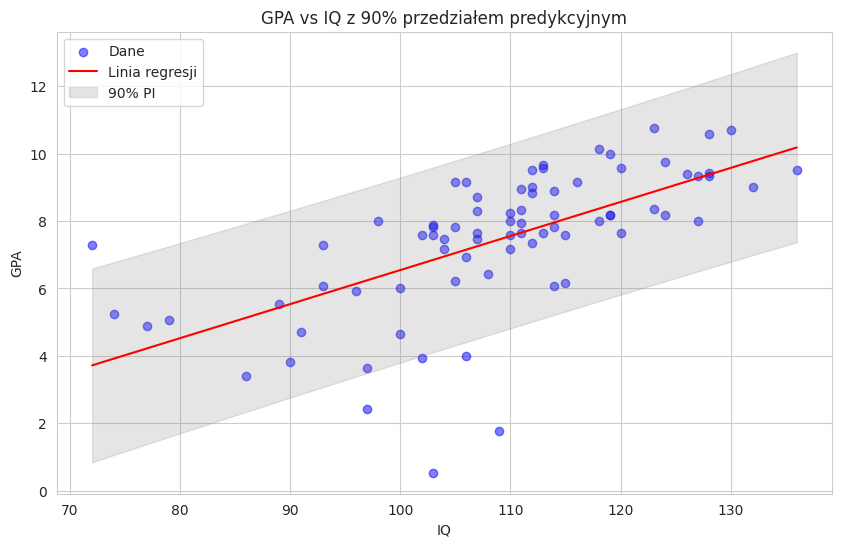

In [31]:
iq_to_predict = np.array([75, 100, 140])
iq_pred_const = sm.add_constant(iq_to_predict)

predictions_90 = model_iq.get_prediction(iq_pred_const).summary_frame(alpha=0.10)

res_c = pd.DataFrame({
    'IQ': iq_to_predict,
    'Przewidywane GPA': predictions_90['mean'].values,
    '90% PI': [f"[{l:.4f}, {h:.4f}]" for l, h in zip(predictions_90['obs_ci_lower'], predictions_90['obs_ci_upper'])]
})

print("Predykcje dla wybranych IQ (Punkt c):")
print(res_c.to_markdown(index=False))

full_pred_90 = model_iq.get_prediction(X_iq_const).summary_frame(alpha=0.10)
outside = df2[(y < full_pred_90['obs_ci_lower']) | (y > full_pred_90['obs_ci_upper'])]

print(f"\nLiczba obserwacji poza 90% przedziałem predykcyjnym: {len(outside)}")
print(f"Procent poza przedziałem: {(len(outside)/n)*100:.2f}%")

plt.figure(figsize=(10, 6))
plt.scatter(x_iq, y, color='blue', alpha=0.5, label='Dane')
order = np.argsort(x_iq)
plt.plot(x_iq.iloc[order], full_pred_90['mean'].iloc[order], color='red', label='Linia regresji')
plt.fill_between(x_iq.iloc[order], full_pred_90['obs_ci_lower'].iloc[order],
                 full_pred_90['obs_ci_upper'].iloc[order], color='gray', alpha=0.2, label='90% PI')
plt.xlabel('IQ')
plt.ylabel('GPA')
plt.title('GPA vs IQ z 90% przedziałem predykcyjnym')
plt.legend()
plt.show()

WYNIKI REGRESJI (Punkt e):
Równanie (IQ): GPA = -3.5571 + 0.1010 * IQ
Równanie (PH): GPA = 2.2259 + 0.0917 * PH

Porównanie współczynników determinacji:
IQ R^2: 0.4016
PH R^2: 0.2936


/tmp/ipykernel_11118/3114099565.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Równanie (IQ): GPA = {model_iq.params[0]:.4f} + {model_iq.params[1]:.4f} * IQ")
/tmp/ipykernel_11118/3114099565.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Równanie (PH): GPA = {model_ph.params[0]:.4f} + {model_ph.params[1]:.4f} * PH")


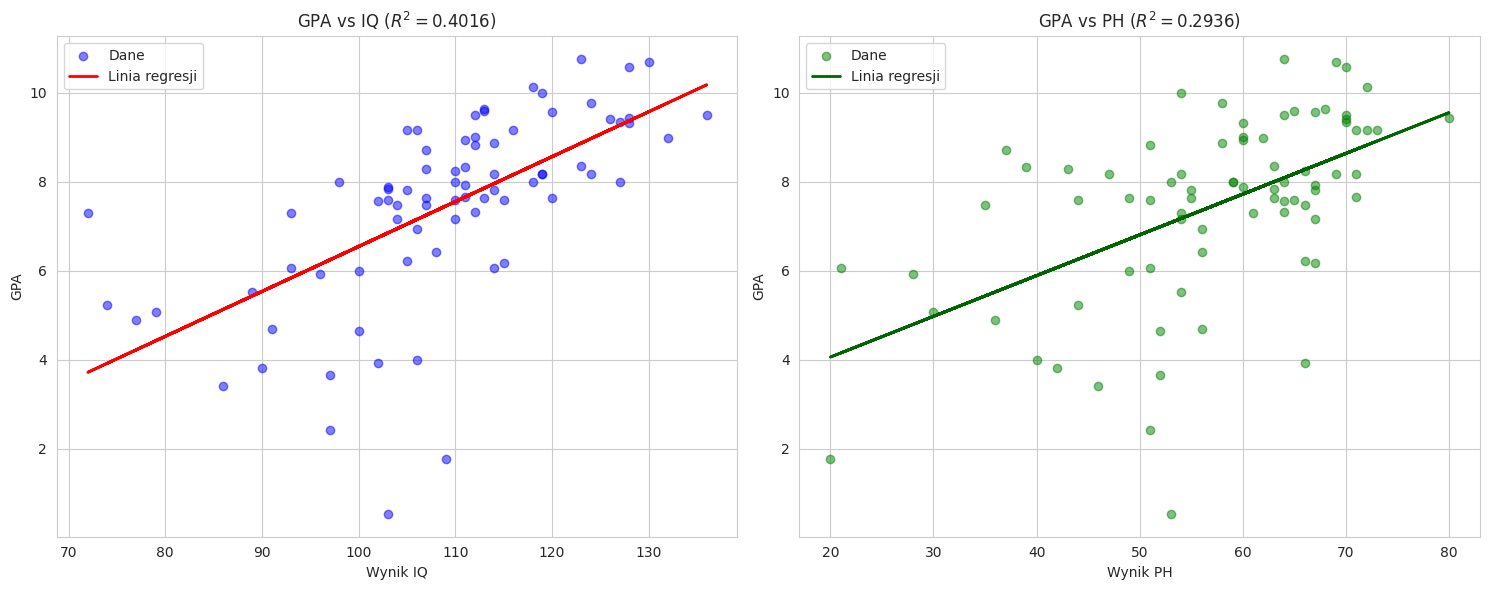

In [35]:
x_ph = df2['PH']
X_ph_const = sm.add_constant(x_ph)
model_ph = sm.OLS(y, X_ph_const).fit()

r2_iq = model_iq.rsquared
r2_ph = model_ph.rsquared

print("WYNIKI REGRESJI (Punkt e):")
print(f"Równanie (IQ): GPA = {model_iq.params[0]:.4f} + {model_iq.params[1]:.4f} * IQ")
print(f"Równanie (PH): GPA = {model_ph.params[0]:.4f} + {model_ph.params[1]:.4f} * PH")

print("\nPorównanie współczynników determinacji:")
print(f'IQ R^2: {r2_iq:.4f}')
print(f'PH R^2: {r2_ph:.4f}')


fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].scatter(x_iq, y, alpha=0.5, color='blue', label='Dane')
ax[0].plot(x_iq, model_iq.predict(X_iq_const), color='red', linewidth=2, label='Linia regresji')
ax[0].set_title(f'GPA vs IQ ($R^2 = {r2_iq:.4f}$)')
ax[0].set_xlabel('Wynik IQ')
ax[0].set_ylabel('GPA')
ax[0].legend()

ax[1].scatter(x_ph, y, alpha=0.5, color='green', label='Dane')
ax[1].plot(x_ph, model_ph.predict(X_ph_const), color='darkgreen', linewidth=2, label='Linia regresji')
ax[1].set_title(f'GPA vs PH ($R^2 = {r2_ph:.4f}$)')
ax[1].set_xlabel('Wynik PH')
ax[1].set_ylabel('GPA')
ax[1].legend()

plt.tight_layout()
plt.show()

## Zadanie 3

In [36]:
n = 200
m = 1000
alpha = 0.05

np.random.seed(42) # Dla powtarzalności wyników
X = np.random.normal(0, np.sqrt(1/500), n)
SXX = np.sum((X - np.mean(X))**2)

In [37]:
def run_simulation(beta1_true, noise_type):
    rejections = 0
    X_const = sm.add_constant(X)

    for _ in range(m):

        if noise_type == 'normal':
            epsilon = np.random.normal(0, 1, n)
        elif noise_type == 'exp':
            epsilon = np.random.exponential(1, n)
        elif noise_type == 'logistic':
            epsilon = np.random.logistic(0, 1, n)

        Y = 5 + beta1_true * X + epsilon

        model = sm.OLS(Y, X_const).fit()
        p_val = model.pvalues[1]

        if p_val < alpha:
            rejections += 1

    return rejections / m

In [38]:
theo_type1 = alpha

beta1_val = 2
sigma_assumed = 1
delta = beta1_val / (sigma_assumed / np.sqrt(SXX))

t_crit = stats.t.ppf(1 - alpha/2, n - 2)

power_theo = (1 - stats.nct.cdf(t_crit, n - 2, delta)) + stats.nct.cdf(-t_crit, n - 2, delta)

In [39]:
results = {
    'Punkt': ['a', 'b', 'c', 'd', 'e', 'f'],
    'beta1': [0, 0, 0, 2, 2, 2],
    'Rozkład szumu': ['Normalny', 'Wykładniczy', 'Logistyczny', 'Normalny', 'Wykładniczy', 'Logistyczny'],
    'Prawd. (Symulacja)': [
        run_simulation(0, 'normal'),
        run_simulation(0, 'exp'),
        run_simulation(0, 'logistic'),
        run_simulation(2, 'normal'),
        run_simulation(2, 'exp'),
        run_simulation(2, 'logistic')
    ],
    'Prawd. (Teoria N(0,1))': [
        theo_type1, theo_type1, theo_type1,
        power_theo, power_theo, power_theo
    ]
}

df_results = pd.DataFrame(results)
df_results['Typ'] = df_results['beta1'].apply(lambda x: 'Błąd I rodzaju' if x == 0 else 'Moc testu')

print("PODSUMOWANIE SYMULACJI (Zadanie 3):")
print(df_results[['Punkt', 'Typ', 'Rozkład szumu', 'Prawd. (Symulacja)', 'Prawd. (Teoria N(0,1))']].to_markdown(index=False))

PODSUMOWANIE SYMULACJI (Zadanie 3):
| Punkt   | Typ            | Rozkład szumu   |   Prawd. (Symulacja) |   Prawd. (Teoria N(0,1)) |
|:--------|:---------------|:----------------|---------------------:|-------------------------:|
| a       | Błąd I rodzaju | Normalny        |                0.065 |                 0.05     |
| b       | Błąd I rodzaju | Wykładniczy     |                0.051 |                 0.05     |
| c       | Błąd I rodzaju | Logistyczny     |                0.059 |                 0.05     |
| d       | Moc testu      | Normalny        |                0.202 |                 0.215359 |
| e       | Moc testu      | Wykładniczy     |                0.23  |                 0.215359 |
| f       | Moc testu      | Logistyczny     |                0.088 |                 0.215359 |


## Zadanie 4

Równanie regresji: Y = 2.5753 + -0.3240 * time
R-kwadrat (R^2): 0.8116
Korelacja (Y_obs vs Y_pred): 0.9009
Test istotności (F-stat): 55.9938, p-value: 4.6112e-06
Stopnie swobody: 13


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_11118/1019284860.py:1: SyntaxWarning: invalid escape sequence '\s'
  data4 = pd.read_csv('../data/CH03PR15.txt', sep='\s+', header=None, names=['concentration', 'time'])
/tmp/ipykernel_11118/1019284860.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Równanie regresji: Y = {model_a.params[0]:.4f} + {model_a.params[1]:.4f} * time")


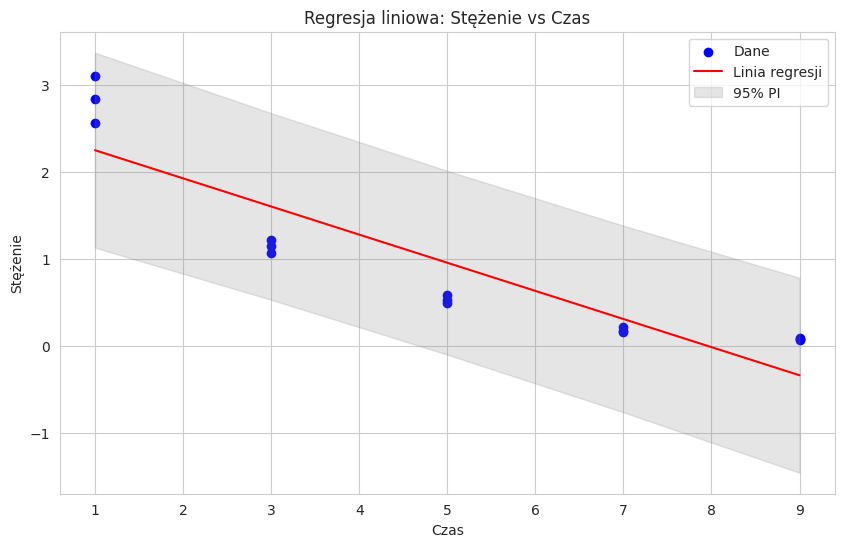

In [43]:
data4 = pd.read_csv('../data/CH03PR15.txt', sep='\s+', header=None, names=['concentration', 'time'])
Y = data4['concentration']
X = data4['time']
n = len(data4)

X_const = sm.add_constant(X)
model_a = sm.OLS(Y, X_const).fit()

pred_a = model_a.get_prediction(X_const).summary_frame(alpha=0.05)
PI_col = [f"[{l:.4f}, {h:.4f}]" for l, h in zip(pred_a['obs_ci_lower'], pred_a['obs_ci_upper'])]

r2_a = model_a.rsquared
corr_a = np.corrcoef(Y, model_a.fittedvalues)[0, 1]

print(f"Równanie regresji: Y = {model_a.params[0]:.4f} + {model_a.params[1]:.4f} * time")
print(f"R-kwadrat (R^2): {r2_a:.4f}")
print(f"Korelacja (Y_obs vs Y_pred): {corr_a:.4f}")
print(f"Test istotności (F-stat): {model_a.fvalue:.4f}, p-value: {model_a.f_pvalue:.4e}")

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Dane')
order = np.argsort(X)
plt.plot(X.iloc[order], model_a.fittedvalues.iloc[order], color='red', label='Linia regresji')
plt.fill_between(X.iloc[order], pred_a['obs_ci_lower'].iloc[order],
                 pred_a['obs_ci_upper'].iloc[order], color='gray', alpha=0.2, label='95% PI')
plt.xlabel('Czas')
plt.ylabel('Stężenie')
plt.title('Regresja liniowa: Stężenie vs Czas')
plt.legend()
plt.show()

In [46]:
Y_bc, lam = boxcox(Y)
print(f"Optymalny parametr lambda (Box-Cox): {lam:.4f}")

Y_log = np.log(Y)
model_log = sm.OLS(Y_log, X_const).fit()

r2_log = model_log.rsquared
pred_log = model_log.get_prediction(X_const).summary_frame(alpha=0.05)

print("\nWyniki modelu log(Y) ~ time:")
print(f"Równanie: log(Y) = {model_log.params[0]:.4f} + {model_log.params[1]:.4f} * time")
print(f"R-kwadrat (R^2): {r2_log:.4f}")
print(f"F-stat: {model_log.fvalue:.4f}, p-value: {model_log.f_pvalue:.4e}")

Optymalny parametr lambda (Box-Cox): 0.0205

Wyniki modelu log(Y) ~ time:
Równanie: log(Y) = 1.5079 + -0.4499 * time
R-kwadrat (R^2): 0.9930
F-stat: 1838.2250, p-value: 2.1883e-15


/tmp/ipykernel_11118/3146756412.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Równanie: log(Y) = {model_log.params[0]:.4f} + {model_log.params[1]:.4f} * time")


Korelacja (Y_obs vs Y_pred_log_model) na skali oryginalnej: 0.9946


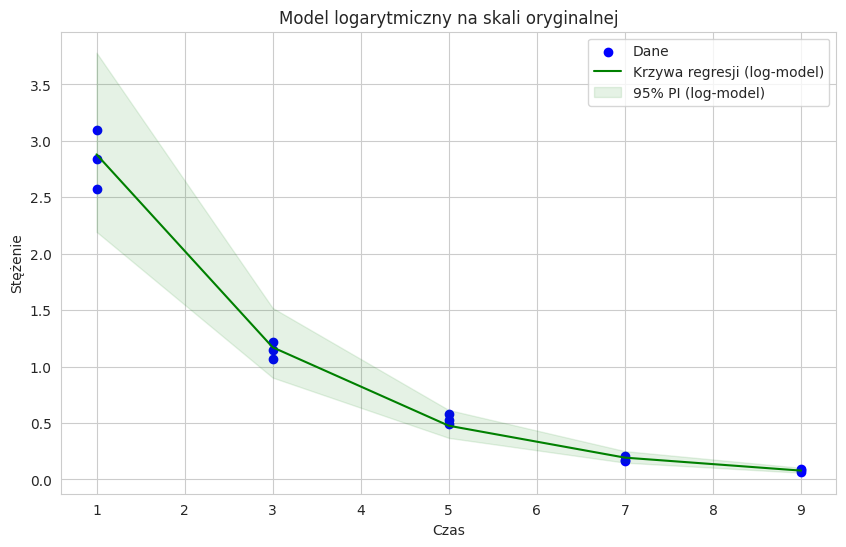

In [47]:
Y_pred_orig = np.exp(model_log.fittedvalues)

PI_low_orig = np.exp(pred_log['obs_ci_lower'])
PI_high_orig = np.exp(pred_log['obs_ci_upper'])

corr_log_orig = np.corrcoef(Y, Y_pred_orig)[0, 1]

print(f"Korelacja (Y_obs vs Y_pred_log_model) na skali oryginalnej: {corr_log_orig:.4f}")

# Wykres
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Dane')
plt.plot(X.iloc[order], Y_pred_orig.iloc[order], color='green', label='Krzywa regresji (log-model)')
plt.fill_between(X.iloc[order], PI_low_orig.iloc[order],
                 PI_high_orig.iloc[order], color='green', alpha=0.1, label='95% PI (log-model)')
plt.xlabel('Czas')
plt.ylabel('Stężenie')
plt.title('Model logarytmiczny na skali oryginalnej')
plt.legend()
plt.show()

In [49]:
X_inv_sqrt = 1 / np.sqrt(X)
X_inv_sqrt_const = sm.add_constant(X_inv_sqrt)
model_f = sm.OLS(Y, X_inv_sqrt_const).fit()

r2_f = model_f.rsquared
corr_f = np.corrcoef(Y, model_f.fittedvalues)[0, 1]

print("Wyniki modelu Y ~ time^(-1/2):")
print(f"R-kwadrat (R^2): {r2_f:.4f}")
print(f"Korelacja (Y_obs vs Y_pred): {corr_f:.4f}")

summary_df = pd.DataFrame({
    'Model': ['Liniowy (a)', 'Logarytmiczny (d)', 'Odwrotność pierwiastka (f)'],
    'R-kwadrat': [r2_a, r2_log, r2_f],
    'Korelacja z Y_obs': [corr_a, corr_log_orig, corr_f]
})
print("\nPorównanie modeli:")
print(summary_df.to_markdown(index=False))

Wyniki modelu Y ~ time^(-1/2):
R-kwadrat (R^2): 0.9881
Korelacja (Y_obs vs Y_pred): 0.9940

Porównanie modeli:
| Model                      |   R-kwadrat |   Korelacja z Y_obs |
|:---------------------------|------------:|--------------------:|
| Liniowy (a)                |    0.811577 |            0.900876 |
| Logarytmiczny (d)          |    0.992978 |            0.994559 |
| Odwrotność pierwiastka (f) |    0.988063 |            0.994014 |
